In [8]:
# Import neccesary libraries.
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import random
import torch
import torch.nn as nn
import torch.optim as optim
from xgboost import XGBRegressor
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import randint, uniform

# Current Approach in improving performance
 - Remove Outliers
 - Remove high dependent variables
 - Use regularization methods
 - Use deep neural networks
 - check assumption
 - Transform the response variable for stable distribution
 - Create more measures (utilities) from the data (e.g. Star Powers)

### Load data and check response distribution

In [9]:
df = pd.read_csv("data/movie_data_encoded.csv")
y = df['revenue']
columns_to_drop = ['status', 'Unnamed: 0', 'name', 'genres', 'directors', 'writers','actors', 'original_language', 'production_companies',
       'release_date','keywords', 'revenue']
X = df.drop(columns_to_drop, axis=1)
y_log = np.log1p(y)

In [10]:
X.head()

,averageRating,numVotes,budget,runtime,trailer_views,trailer_likes,titleType_movie,titleType_tvMovie,director_score,writer_score,...,production_popular,lang_en,lang_fr,lang_es,lang_hi,lang_ja,lang_other,has_trailer,has_keywords,keyword_embedding
0,5.5,71.0,6.967033e+07,95.0,2.021111e+06,7.930411e+05,1.0,0.0,0,0,...,0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1,0.160210
1,5.8,117.0,0.000000e+00,110.0,-8.548080e+05,8.382362e+05,1.0,0.0,0,0,...,0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1,0.146542
2,6.1,27298.0,3.105832e+06,193.0,6.904190e+06,3.549670e+06,1.0,0.0,0,0,...,0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1,0.248196
3,6.5,2932.0,5.376505e+05,59.0,3.040960e+04,4.040880e+04,1.0,0.0,1,0,...,1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0,-1.267071
4,5.3,85.0,4.692912e+05,45.0,1.556221e+04,4.354229e+04,1.0,0.0,1,1,...,0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1,-0.141316


In [11]:
def check_revenue_distribution(series):
    plt.figure(figsize=(8,5))
    sns.histplot(series, bins=50, kde=True)
    plt.title("Revenue Distribution")
    plt.show()

In [ ]:
# In million
round(y.describe() / 1e6, 2)

count      0.01
mean      27.37
std       44.03
min        0.00
25%        2.29
50%       13.36
75%       34.95
max      908.01
Name: revenue, dtype: float64

In [13]:
round(X['star_score'].describe(), 2)

count    11362.00
mean        75.79
std        126.70
min          0.00
25%          0.00
50%          0.00
75%        107.00
max       1566.00
Name: star_score, dtype: float64

In [14]:
#check_revenue_distribution(y)

In [15]:
#check_revenue_distribution(y_log)

### Transform Data and do train/test split

In [ ]:
'''
# Check VIF of each variable
vif = pd.DataFrame()
vif["feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i)
              for i in range(len(X.columns))]
'''

'\n# Check VIF of each variable\nvif = pd.DataFrame()\nvif["feature"] = X.columns\nvif["VIF"] = [variance_inflation_factor(X.values, i)\n              for i in range(len(X.columns))]\n'

In [17]:
'''vif'''

'vif'

In [ ]:
'''for i in vif[vif["VIF"] > 10]['feature']:
    X.drop(i, axis=1)'''

'for i in vif[vif["VIF"] > 10][\'feature\']:\n    X.drop(i, axis=1)'

In [19]:
# 1.1 Detect and handle outliers using IQR method
def handle_outliers(df, columns, method='cap'):
    df_clean = df.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.05)
        Q3 = df_clean[col].quantile(0.95)
        IQR = Q3 - Q1
        lower_bound = Q1 - 2 * IQR
        upper_bound = Q3 + 2 * IQR

        if method == 'cap':
            df_clean[col] = df_clean[col].clip(lower_bound, upper_bound)

    return df_clean

# Identify numeric columns for outlier handling
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
X_clean = handle_outliers(X, numeric_cols, method='cap')

In [ ]:
# Split original data
X_train, X_test, y_train, y_test = train_test_split(X_clean, y, test_size=0.2, random_state=42)

# Apply log1p to y_train only
y_train_log = np.log1p(y_train)  # Train on log-transformed target

# Create polynomial features (For complex interaction)
poly = PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

feature_names = poly.get_feature_names_out(X.columns)

# Scale features using training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

scaler_poly = StandardScaler()
X_train_poly_scaled = scaler_poly.fit_transform(X_train_poly)
X_test_poly_scaled = scaler_poly.transform(X_test_poly)

### Dummy model performance

In [14]:
# Check the performance of the dummy variable
dummy_pred = np.full_like(y_test, y_train.mean())
RMSE = np.sqrt(mean_squared_error(y_test, dummy_pred))
R2 = r2_score(y_test, dummy_pred)

# Format RMSE (e.g., in millions)
print(f"RMSE: {round(RMSE / 1e6, 2)} Millions, R²: {round(R2, 2)}")

RMSE: 41.46 Millions, R²: -0.0


### Random Forest Regressor

In [ ]:
RFR_tune = RandomForestRegressor(random_state=42)
param_dist = {
    'n_estimators': randint(100, 1000),
    'max_depth': [5, 10, 20, 30, None],
    'min_samples_split': [2, 5, 10],  # Prevents overfitting
    'min_samples_leaf': [1, 2, 4],  # Controls minimum samples per leaf
    'max_features': ['sqrt', 'log2', 0.5, None]  # Feature selection method
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

rand_search = RandomizedSearchCV(RFR_tune, param_distributions=param_dist, 
        n_iter=10, cv=kf, scoring='neg_mean_squared_error', random_state=42, n_jobs=-1)

# Fit the random search object to the data.
rand_search.fit(X_train_poly_scaled, y_train_log.values.ravel())
rand_search.best_estimator_

In [18]:
Best_RFR = rand_search.best_estimator_
y_pred = np.expm1(Best_RFR.predict(X_test_poly_scaled))
RMSE = np.sqrt(mean_squared_error(y_test, y_pred))
R2 = r2_score(y_test, y_pred)
# Format RMSE (e.g., in millions)wwww
print(f"RMSE: {round(RMSE / 1e6, 2)} Millions, R²: {round(R2, 2)}")

RMSE: 29.18 Millions, R²: 0.5


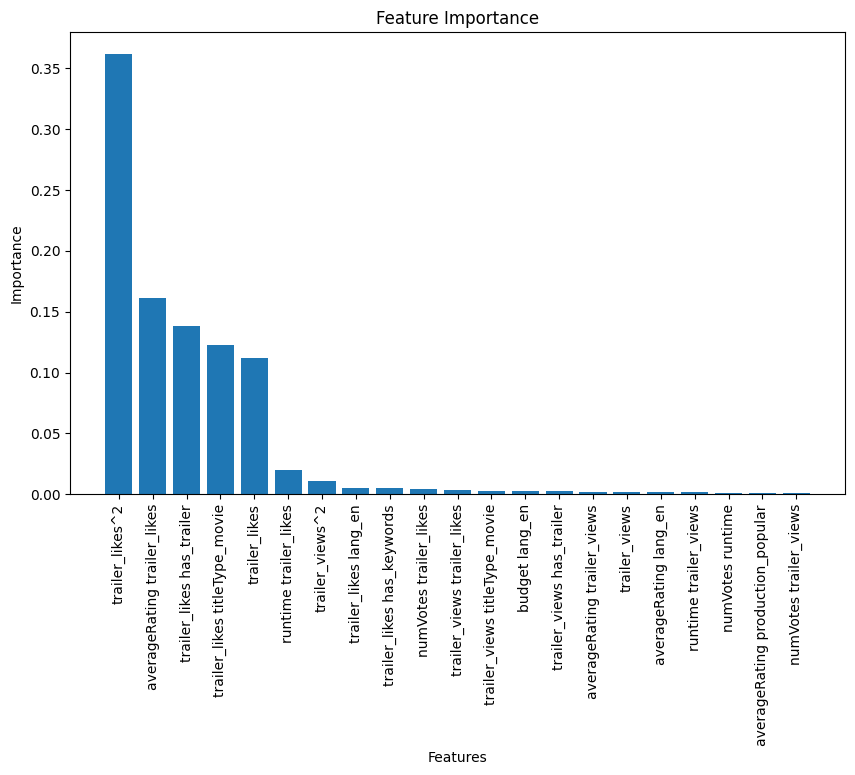

In [18]:
importances = Best_RFR.feature_importances_

feature_importances = pd.DataFrame(Best_RFR.feature_importances_, index=feature_names, columns=["importance"]).sort_values("importance", ascending=False)

# Select important features (importance >= 0.05)
important_features = feature_importances[feature_importances["importance"] >= 0.001].index

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.title("Feature Importance")

# Get corresponding importance values
important_importance_values = feature_importances.loc[important_features, "importance"]

# Plot
plt.bar(range(len(important_features)), important_importance_values, align="center")
plt.xticks(range(len(important_features)), important_features, rotation=90)

plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

In [19]:
# Map feature names to column indices
important_feature_indices = [i for i, name in enumerate(feature_names) if name in important_features]

# Select only important features using integer indices
X_train_poly_scaled = X_train_poly_scaled[:, important_feature_indices]
X_test_poly_scaled = X_test_poly_scaled[:, important_feature_indices]

### Boosting Methods

In [22]:
'''
GDB_tune = GradientBoostingRegressor()
param_grid = {
    'n_estimators': [50, 100, 200],  # Number of boosting stages
    'learning_rate': [0.01, 0.1, 0.2],  # Step size shrinkage
    'max_depth': [3, 5, 7],  # Depth of each tree
    'min_samples_split': [2, 5, 10],  # Minimum samples to split an internal node
    'min_samples_leaf': [1, 2, 4],  # Minimum samples at a leaf node
    'subsample': [0.8, 1.0],  # Fraction of samples used for training each tree
    'max_features': ['sqrt', 'log2', None]  # Number of features per tree
}

rand_search = RandomizedSearchCV(GDB_tune, param_distributions=param_grid, cv=5, n_jobs=1)

# Fit the random search object to the data.
rand_search.fit(X_train_poly_scaled, y_train_log.values.ravel())
rand_search.best_estimator_'
'''

"\nGDB_tune = GradientBoostingRegressor()\nparam_grid = {\n    'n_estimators': [50, 100, 200],  # Number of boosting stages\n    'learning_rate': [0.01, 0.1, 0.2],  # Step size shrinkage\n    'max_depth': [3, 5, 7],  # Depth of each tree\n    'min_samples_split': [2, 5, 10],  # Minimum samples to split an internal node\n    'min_samples_leaf': [1, 2, 4],  # Minimum samples at a leaf node\n    'subsample': [0.8, 1.0],  # Fraction of samples used for training each tree\n    'max_features': ['sqrt', 'log2', None]  # Number of features per tree\n}\n\nrand_search = RandomizedSearchCV(GDB_tune, param_distributions=param_grid, cv=5, n_jobs=1)\n\n# Fit the random search object to the data.\nrand_search.fit(X_train_poly_scaled, y_train_log.values.ravel())\nrand_search.best_estimator_'\n"

In [23]:
GDB = GradientBoostingRegressor(max_depth=5, max_features='sqrt', min_samples_leaf=2, min_samples_split=10, n_estimators=200, subsample=0.8, random_state=42)
GDB.fit(X_train_poly_scaled, y_train_log.values.ravel())
#y_pred = GDB.predict(X_test_poly_scaled)
y_pred = np.expm1(GDB.predict(X_test_poly_scaled))
RMSE = np.sqrt(mean_squared_error(y_test, y_pred))
R2 = r2_score(y_test, y_pred)
# Format RMSE (e.g., in millions)wwww
print(f"RMSE: {round(RMSE / 1e6, 2)} Millions, R²: {round(R2, 2)}")

RMSE: 28.47 Millions, R²: 0.53


In [21]:
# Define XGBoost base model
xgb_model = XGBRegressor(objective='reg:squarederror', random_state=42)

# Fine-tuned parameter search space based on previous results
param_dist = {
    'n_estimators': randint(400, 800),
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': uniform(0.05, 0.15),
    'subsample': uniform(0.7, 0.3),
    'colsample_bytree': uniform(0.7, 0.3),
    'min_child_weight': [1, 2, 3, 4],
    'gamma': uniform(0, 0.1)
}

# Use K-Fold cross-validation with more folds for better stability
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Setup RandomizedSearchCV with more iterations
rand_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=80,
    cv=kf,
    scoring='neg_mean_squared_error',
    random_state=42,
    verbose=1,
    n_jobs=-1
)

print("Training XGBoost with focused parameter search...")
rand_search.fit(X_train_scaled, y_train_log)
best_xgb = rand_search.best_estimator_
print("Best Hyperparameters:", rand_search.best_params_)

Training XGBoost with focused parameter search...
Fitting 5 folds for each of 80 candidates, totalling 400 fits
Best Hyperparameters: {'colsample_bytree': np.float64(0.9908610601342476), 'gamma': np.float64(0.07145951041799521), 'learning_rate': np.float64(0.056160127515181374), 'max_depth': 5, 'min_child_weight': 4, 'n_estimators': 457, 'subsample': np.float64(0.7235369144026798)}


In [22]:
# Evaluate XGBoost
y_pred_xgb_log = best_xgb.predict(X_test_scaled)
y_pred_xgb = np.expm1(y_pred_xgb_log)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb)) / 1e6
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost Final Model - RMSE: {rmse_xgb:.2f} millions, R^2: {r2_xgb:.4f}")


XGBoost Final Model - RMSE: 27.16 millions, R^2: 0.5707


In [23]:
# 5.1 Adding Weight Adjustments for High-Revenue Movies

# Create a copy of the best model
high_revenue_threshold = np.percentile(y_train, 90)
is_high_revenue = y_train > high_revenue_threshold

# Create sample weights - give twice the weight to high revenue samples
sample_weights = np.ones(len(y_train))
sample_weights[is_high_revenue] = 2.0

# Train a weighted model
weighted_xgb = XGBRegressor(**rand_search.best_params_, random_state=42)
weighted_xgb.fit(X_train_scaled, y_train_log, sample_weight=sample_weights)

# Evaluate weighted model
y_pred_weighted_log = weighted_xgb.predict(X_test_scaled)
y_pred_weighted = np.expm1(y_pred_weighted_log)

rmse_weighted = np.sqrt(mean_squared_error(y_test, y_pred_weighted)) / 1e6
r2_weighted = r2_score(y_test, y_pred_weighted)

print(f"Weighted XGBoost Model - RMSE: {rmse_weighted:.2f} Millions, R^2: {r2_weighted:.4f}")


Weighted XGBoost Model - RMSE: 27.14 Millions, R^2: 0.5716


In [24]:
# 5.2 Try a simpler approach for high-value samples using separate models
# Train a model specifically for high-value samples
high_value_threshold = np.percentile(y_train, 75)  # 75th percentile
train_high_mask = y_train > high_value_threshold
test_high_mask = y_test > high_value_threshold

if sum(train_high_mask) > 50:
    xgb_high = XGBRegressor(
        n_estimators=500,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
    xgb_high.fit(X_train_scaled[train_high_mask], y_train_log[train_high_mask])

    # Create a combined prediction array
    y_pred_combined_log = y_pred_xgb_log.copy()

    # Use high-value model predictions for high-value test samples
    if sum(test_high_mask) > 0:
        y_pred_high_log = xgb_high.predict(X_test_scaled[test_high_mask])
        y_pred_combined_log[test_high_mask] = y_pred_high_log

    # Convert to original scale
    y_pred_combined = np.expm1(y_pred_combined_log) 

    # Evaluate combined model
    rmse_combined = np.sqrt(mean_squared_error(y_test, y_pred_combined)) / 1e6
    r2_combined = r2_score(y_test, y_pred_combined)

    print(f"Combined Model Approach - RMSE: {rmse_combined:.2f} Millions, R^2: {r2_combined:.4f}")
else:
    print("Not enough high-value samples to train a separate model")


Combined Model Approach - RMSE: 24.99 Millions, R^2: 0.6368


### Muti-Layer Perceptron 

In [24]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)         # If using GPU
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)  # Call this before model initialization and training

In [29]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, output_dim, dropout=0.2):
        super(MLP, self).__init__()
        layers = []
        last_dim = input_dim
        for h_dim in hidden_dims:
            layers.append(nn.Linear(last_dim, h_dim))
            layers.append(nn.BatchNorm1d(h_dim))  # Stabilize training
            layers.append(nn.ELU(alpha=1.0))
            layers.append(nn.Dropout(dropout))    # Regularization
            last_dim = h_dim
        layers.append(nn.Linear(last_dim, output_dim))
        self.model = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.model(x)
    
def create_model():
    model = MLP(input_dim, hidden_dims, output_dim)  # Use your existing MLP class
    return model

input_dim = 21      # Number of input features
hidden_dims = [64,32]  # Two hidden layers with 64 and 32 neurons
output_dim = 1      # For regression 

model = MLP(input_dim, hidden_dims, output_dim)
print(model)

# Convert to tensors once
X_tensor = torch.tensor(X_train_poly_scaled, dtype=torch.float)
y_tensor = torch.tensor(y_train_log.values, dtype=torch.float).view(-1, 1)

# Set up k-fold cross-validation
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)
fold_performances = []

# Early stopping parameters
num_epochs = 10000
patience = 1000  # Stop if no improvement for `patience` epochs

for fold, (train_index, val_index) in enumerate(kf.split(X_tensor)):
    print(f"\nFold {fold+1}")
    X_train_cv = X_tensor[train_index]
    y_train_cv = y_tensor[train_index]
    X_val_cv = X_tensor[val_index]
    y_val_cv = y_tensor[val_index]

    model = create_model()
    optimizer = optim.Adam(model.parameters(), lr=0.1, weight_decay=1e-4)
    criterion = nn.MSELoss()

    best_val_loss = float('inf')  # Store best loss (initially very high)
    epochs_without_improvement = 0  
      
    for epoch in range(num_epochs):
        if epoch > 1000: # Fine tuning
            for param_group in optimizer.param_groups:
                param_group["lr"] = 0.01
        elif epoch > 3000:
            for param_group in optimizer.param_groups:
                param_group["lr"] = 0.0001
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train_cv)
        loss = criterion(outputs, y_train_cv)
        loss.backward()
        optimizer.step()

    # Evaluate on validation fold
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_cv)
        val_loss = criterion(val_outputs, y_val_cv).item()

    # Early stopping check
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f"Early stopping at epoch {epoch+1}, best val loss: {best_val_loss:.4f}")
            break

        if (epoch + 1) % 100 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {loss.item():.4f}, Val Loss: {val_loss:.4f}")

    fold_performances.append(best_val_loss)

avg_val_loss = np.mean(fold_performances)
print(f"\nAverage Validation Loss across {k} folds: {avg_val_loss:.4f}")

MLP(
  (model): Sequential(
    (0): Linear(in_features=21, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ELU(alpha=1.0)
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ELU(alpha=1.0)
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)

Fold 1
Epoch [10000/10000], Train Loss: 0.9487, Val Loss: 1.8211

Fold 2
Epoch [10000/10000], Train Loss: 0.9162, Val Loss: 1.3527

Fold 3
Epoch [10000/10000], Train Loss: 0.9673, Val Loss: 0.8165

Fold 4
Epoch [10000/10000], Train Loss: 0.9461, Val Loss: 0.7886

Fold 5
Epoch [10000/10000], Train Loss: 0.9531, Val Loss: 0.9031

Average Validation Loss across 5 folds: 1.1364


In [28]:
X_test_tensor = torch.tensor(X_test_poly_scaled, dtype=torch.float)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float).view(-1, 1)

# Evaluation
model.eval()
with torch.no_grad():
    test_outputs_log = model(X_test_tensor)

    # Compute test loss in log space
    test_loss = criterion(test_outputs_log, y_test_tensor)

    # Convert both predictions and ground truth back to original scale
    test_outputs = torch.expm1(test_outputs_log)  # Predictions in original scale
    y_test_original = torch.expm1(y_test_tensor)  # Ground truth in original scale

    # Compute RMSE in original scale
    mse = torch.mean((test_outputs - y_test_original) ** 2)
    rmse = torch.sqrt(mse) / 1e6  # Convert RMSE to millions

    # Compute R² in original scale
    ss_res = torch.sum((y_test_original - test_outputs) ** 2)
    ss_tot = torch.sum((y_test_original - torch.mean(y_test_original)) ** 2)
    r2 = 1 - (ss_res / ss_tot)

print(f'Test Loss (Log Scale): {test_loss.item():.4f}, RMSE: {rmse.item():.4f} Millions, R²: {r2.item():.4f}')

Test Loss (Log Scale): 2450235355824128.0000, RMSE: inf Millions, R²: nan
